# bcNMF on MDD: case/control recovery

Astrocytes and oligodendrocytes from 4 MDD and 4 matched control donors, raw counts over 3,000 HVGs.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore'); sys.modules['tensorflow'] = None
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'bcnmf_reproducibility/src'))
DATA = Path.cwd() / 'data'

import numpy as np, pandas as pd, anndata as ad, umap
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score as ARI
from bcnmf import contrastive_nmf_sse, contrastive_nmf_poisson

dense = lambda m: np.ascontiguousarray(m.toarray() if hasattr(m, 'toarray') else np.asarray(m), dtype=np.float64)
cpm   = lambda A: np.log1p(A / (A.sum(1, keepdims=True) + 1e-12) * 1e4)
nrm   = lambda H: H / (H.sum(1, keepdims=True) + 1e-12)
km    = lambda Z, nc=2: KMeans(nc, random_state=42, n_init=10).fit_predict(Z)

In [2]:
a = ad.read_h5ad(DATA/'mdd/mdd_target_1147x3000.h5ad')
labels = (a.obs['Condition'].to_numpy() == 'Case').astype(int)
Xc = dense(a.X)
Yc = Xc[labels == 0]
names = ['Control', 'Case']
print(f'target {Xc.shape}  background {Yc.shape}  labels {np.bincount(labels)}')

target (1147, 3000)  background (532, 3000)  labels [532 615]


In [3]:
K, ALPHA, NITER = 20, 300.0, 100
W, H_X, H_Y, _ = contrastive_nmf_poisson(Xc.T, Yc.T, K, ALPHA, niter=NITER,
                                         seed=0, damping=0.5, verbose=False)
H = np.asarray(H_X).T
print(f'W {np.asarray(W).shape}   H_X {H.shape}')

W (3000, 20)   H_X (1147, 20)


In [4]:
def embed(H):
    return umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.2,
                     metric='euclidean', random_state=42).fit_transform(H)

def score(H):
    return ARI(labels, km(embed(H)))

emb = embed(H)
ari = ARI(labels, km(emb))
print(f'ARI = {ari:.4f}')

ARI = 0.2213


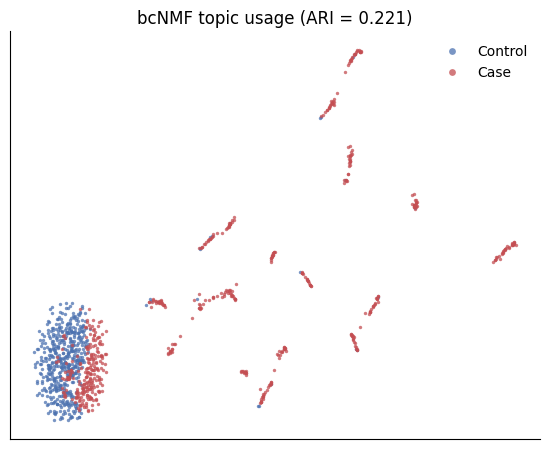

In [5]:
fig, ax = plt.subplots(figsize=(5.6, 4.6))
for v, colour in zip(np.unique(labels), ['#4C72B0', '#C44E52']):
    s = labels == v
    ax.scatter(emb[s, 0], emb[s, 1], s=6, c=colour, label=names[v], alpha=0.75, lw=0)
ax.legend(frameon=False, markerscale=2)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f'bcNMF topic usage (ARI = {ari:.3f})')
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.savefig('mdd.png', dpi=150)

In [6]:
vals = []
for s in [0, 1, 2, 3, 4]:
    _, h, _, _ = contrastive_nmf_poisson(Xc.T, Yc.T, K, ALPHA, niter=NITER,
                                         seed=s, damping=0.5, verbose=False)
    Hs = np.asarray(h).T
    vals.append(score(Hs))
    print(f'  seed {s}  ARI = {vals[-1]:.4f}')
print(f'\nmean {np.mean(vals):.4f} +/- {np.std(vals):.4f}')

  seed 0  ARI = 0.2213


  seed 1  ARI = 0.1714


  seed 2  ARI = 0.1971


  seed 3  ARI = 0.2627


  seed 4  ARI = 0.0531

mean 0.1811 +/- 0.0707
